# STAGE 1 — DATA INGESTION AND QUALITY ASSESSMENT

This notebook performs data ingestion and quality assessment for the London housing price prediction task.

**Random state used throughout: 42**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random state
rng = np.random.default_rng(42)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')

## 1. Load Datasets

Load both datasets and print shapes, column names, and data types.

In [10]:
# Load house prices dataset
house_prices = pd.read_csv('london_house_prices.csv')
print('London House Prices Dataset:')
print(f'Shape: {house_prices.shape}')
print('\nColumn names and types:')
print(house_prices.dtypes)
print('\nFirst 3 rows:')
house_prices.head(3)

London House Prices Dataset:
Shape: (417561, 12)

Column names and types:
outcode          object
latitude        float64
longitude       float64
bedrooms        float64
bathrooms       float64
floorAreaSqM    float64
livingRooms     float64
propertyType     object
tenure           object
energyRating     object
rentEstimate    float64
price           float64
dtype: object

First 3 rows:


,outcode,latitude,longitude,bedrooms,bathrooms,floorAreaSqM,livingRooms,propertyType,tenure,energyRating,rentEstimate,price
0,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,Purpose Built Flat,Leasehold,NaN,2350.0,600000.0
1,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,Flat/Maisonette,Leasehold,NaN,2350.0,600000.0
2,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,Flat/Maisonette,Leasehold,C,2950.0,759000.0


In [11]:
# Load area features dataset
area_features = pd.read_csv('london_area_features.csv')
print('London Area Features Dataset:')
print(f'Shape: {area_features.shape}')
print('\nColumn names and types:')
print(area_features.dtypes)
print('\nFirst 3 rows:')
area_features.head(3)

London Area Features Dataset:
Shape: (168, 52)

Column names and types:
outcode                                object
outcode_lat                           float64
outcode_lon                           float64
n_properties                            int64
crime_anti_social_behaviour             int64
crime_bicycle_theft                     int64
crime_burglary                          int64
crime_criminal_damage_and_arson         int64
crime_drugs                             int64
crime_other_crime                       int64
crime_other_theft                       int64
crime_possession_of_weapons             int64
crime_public_order                      int64
crime_robbery                           int64
crime_shoplifting                       int64
crime_theft_from_the_person             int64
crime_vehicle_crime                     int64
crime_violence_and_sexual_offences      int64
crime_total                             int64
census_denom_total                    float64
census_e

,outcode,outcode_lat,outcode_lon,n_properties,crime_anti_social_behaviour,crime_bicycle_theft,crime_burglary,crime_criminal_damage_and_arson,crime_drugs,crime_other_crime,crime_other_theft,crime_possession_of_weapons,crime_public_order,crime_robbery,crime_shoplifting,crime_theft_from_the_person,crime_vehicle_crime,crime_violence_and_sexual_offences,crime_total,census_denom_total,census_employed_total_perc,census_retired_perc,census_unemployed_perc,census_age_16_to_34_perc,census_age_65_plus_perc,census_level4_perc,census_no_qualifications_perc,poi_bakery,poi_bank,poi_bar,poi_bus_station,poi_cafe,poi_clinic,poi_community_centre,poi_conference_centre,poi_coworking_space,poi_disused,poi_doctors,poi_dojo,poi_fast_food,poi_ferry_terminal,poi_leisure_centre,poi_library,poi_office,poi_pub,poi_restaurant,poi_serviced_office,poi_stock_exchange,poi_townhall,poi_university,poi_vehicle_inspection,poi_total
0,E1,51.517014,-0.060880,2260,3949,386,429,431,699,76,698,54,568,233,142,395,624,2230,10914,745.721649,52.448759,6.852868,4.750019,42.311847,6.805124,42.507906,20.218980,0,0,5,0,54,0,0,0,0,0,0,0,72,0,0,3,0,20,58,0,0,0,2,0,214
1,E10,51.567214,-0.013404,3879,2266,99,248,331,386,69,554,39,380,160,217,151,705,1710,7315,770.102439,60.336661,9.132168,4.841756,32.286032,8.503910,42.694690,19.135622,0,0,11,0,38,0,0,0,1,0,0,0,37,0,0,2,0,11,46,0,0,0,0,0,146
2,E11,51.570297,0.015043,5177,1340,49,217,219,200,46,404,16,262,101,123,85,472,1031,4565,620.167883,62.100222,14.333071,3.957206,27.928930,13.097735,50.591218,14.538071,0,0,7,0,35,0,0,0,0,0,0,0,27,0,0,4,0,11,51,0,0,0,0,0,135


## 2. Missing Values Analysis

In [12]:
# Missing values in house_prices
print('House Prices - Missing Values:')
missing_house = house_prices.isnull().sum()
missing_pct_house = (missing_house / len(house_prices)) * 100
missing_df_house = pd.DataFrame({
    'Count': missing_house,
    '%': missing_pct_house
}).round(2)
print(missing_df_house[missing_df_house['Count'] > 0])

# Missing values in area_features
print('\n\nArea Features - Missing Values:')
missing_area = area_features.isnull().sum()
missing_pct_area = (missing_area / len(area_features)) * 100
missing_df_area = pd.DataFrame({
    'Count': missing_area,
    '%': missing_pct_area
}).round(2)
print(missing_df_area[missing_df_area['Count'] > 0])

House Prices - Missing Values:
              Count      %
bedrooms      40404   9.68
bathrooms     77755  18.62
floorAreaSqM  25066   6.00
livingRooms   60341  14.45
propertyType   1126   0.27
tenure        11494   2.75
energyRating  84288  20.19
rentEstimate   1101   0.26


Area Features - Missing Values:
Empty DataFrame
Columns: [Count, %]
Index: []


## 3. Price Column Outlier Analysis

Check for outliers in the price column using IQR method and visualize distribution.

Price Statistics:
count    4.175610e+05
mean     9.045188e+05
std      9.202917e+05
min      8.900000e+04
25%      4.460000e+05
50%      6.220000e+05
75%      9.840000e+05
max      2.922000e+07
Name: price, dtype: float64

Outliers using IQR (1.5 rule): 37210 (8.9%)
Lower bound: £-361,000, Upper bound: £1,791,000


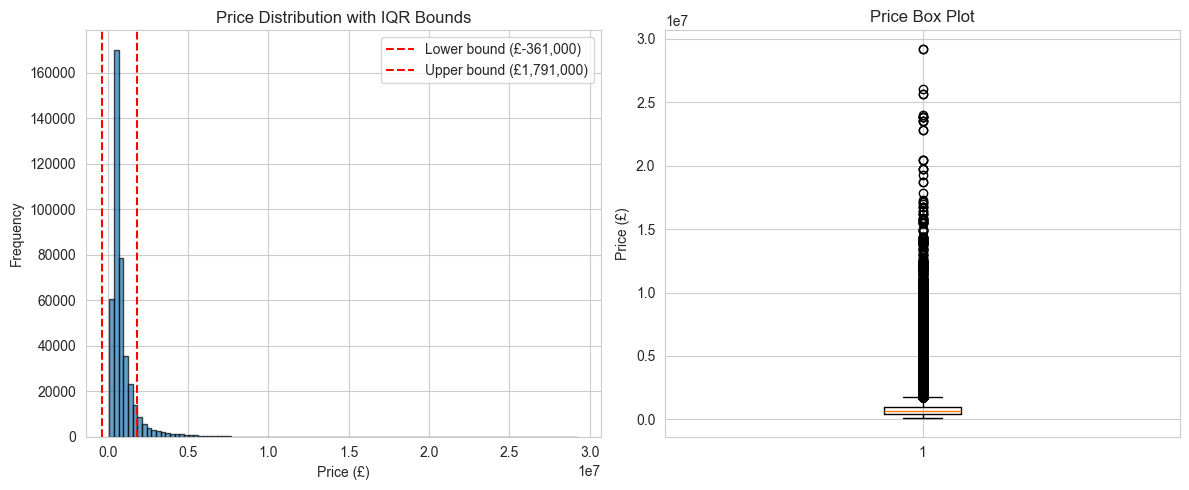

In [13]:
# Price statistics
print('Price Statistics:')
print(house_prices['price'].describe())

# IQR outlier detection
Q1 = house_prices['price'].quantile(0.25)
Q3 = house_prices['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = house_prices[(house_prices['price'] < lower_bound) | (house_prices['price'] > upper_bound)]
print(f'\nOutliers using IQR (1.5 rule): {len(price_outliers)} ({len(price_outliers)/len(house_prices)*100:.1f}%)')
print(f'Lower bound: £{lower_bound:,.0f}, Upper bound: £{upper_bound:,.0f}')

# Visualize price distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(house_prices['price'], bins=100, edgecolor='black', alpha=0.7)
plt.axvline(lower_bound, color='red', linestyle='--', label=f'Lower bound (£{lower_bound:,.0f})')
plt.axvline(upper_bound, color='red', linestyle='--', label=f'Upper bound (£{upper_bound:,.0f})')
plt.title('Price Distribution with IQR Bounds')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(house_prices['price'])
plt.title('Price Box Plot')
plt.ylabel('Price (£)')

plt.tight_layout()
plt.show()

## 4. Merge Datasets

Merge on 'outcode' column.

In [14]:
# Check outcode uniqueness
print('House prices outcode value counts:')
print(house_prices['outcode'].value_counts().head())
print('\nArea features outcode value counts:')
print(area_features['outcode'].value_counts().head())

# Merge datasets
merged_df = house_prices.merge(area_features, on='outcode', how='left', suffixes=('_house', '_area'))
print(f'\nMerged dataset shape: {merged_df.shape}')
print(f'Lost {len(house_prices) - len(merged_df)} rows due to missing outcodes ({(len(house_prices) - len(merged_df))/len(house_prices)*100:.1f}%)')

# Check merge quality
print('\nMerged dataset columns:')
print(list(merged_df.columns))
print('\nSample of merged data:')
merged_df[['outcode', 'price', 'rentEstimate', 'latitude', 'longitude', 'bedrooms']].head()

House prices outcode value counts:
outcode
SE18    8300
E17     7458
SW2     7243
N16     7240
SW16    7188
Name: count, dtype: int64

Area features outcode value counts:
outcode
E1      1
SW1P    1
SW15    1
SW16    1
SW17    1
Name: count, dtype: int64

Merged dataset shape: (417561, 63)
Lost 0 rows due to missing outcodes (0.0%)

Merged dataset columns:
['outcode', 'latitude', 'longitude', 'bedrooms', 'bathrooms', 'floorAreaSqM', 'livingRooms', 'propertyType', 'tenure', 'energyRating', 'rentEstimate', 'price', 'outcode_lat', 'outcode_lon', 'n_properties', 'crime_anti_social_behaviour', 'crime_bicycle_theft', 'crime_burglary', 'crime_criminal_damage_and_arson', 'crime_drugs', 'crime_other_crime', 'crime_other_theft', 'crime_possession_of_weapons', 'crime_public_order', 'crime_robbery', 'crime_shoplifting', 'crime_theft_from_the_person', 'crime_vehicle_crime', 'crime_violence_and_sexual_offences', 'crime_total', 'census_denom_total', 'census_employed_total_perc', 'census_retired_perc'

,outcode,price,rentEstimate,latitude,longitude,bedrooms
0,EC4A,600000.0,2350.0,51.517282,-0.110314,1.0
1,EC4A,600000.0,2350.0,51.517282,-0.110314,NaN
2,SW1P,759000.0,2950.0,51.495505,-0.132379,2.0
3,SE5,388000.0,2000.0,51.478185,-0.092201,1.0
4,N10,1261000.0,4850.0,51.588774,-0.139599,4.0


## 5. Data Quality Issues Summary & Fixes

### Issues Identified:
1. **Missing Values**: List from earlier analysis
2. **Price Outliers**: {len(price_outliers)} extreme values identified
3. **Merge losses**: Some outcodes may not have area features

### Proposed Fixes (to be implemented):
- **Numeric missing values**: Impute with median
- **Categorical missing values**: Impute with mode
- **Price outliers**: Cap at 1% and 99% percentiles (winsorizing) to preserve data
- **Zero/negative values**: Clip to small positive values where appropriate

In [15]:
# Fix missing values in numeric columns (median imputation)
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col != 'outcode':  # Skip outcode if numeric
        median_val = merged_df[col].median()
        merged_df[col] = merged_df[col].fillna(median_val)

print('Missing values after numeric imputation:')
print(merged_df[numeric_cols].isnull().sum().sum())

# Fix categorical columns
categorical_cols = merged_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    mode_val = merged_df[col].mode()[0] if not merged_df[col].mode().empty else 'Unknown'
    merged_df[col] = merged_df[col].fillna(mode_val)

print('\nAll missing values fixed. Final dataset shape:', merged_df.shape)

Missing values after numeric imputation:
0

All missing values fixed. Final dataset shape: (417561, 63)


Price winsorizing bounds: £228,000 - £4,959,000

Price stats after outlier treatment:
count    4.175610e+05
mean     8.877410e+05
std      7.932421e+05
min      2.280000e+05
25%      4.460000e+05
50%      6.220000e+05
75%      9.840000e+05
max      4.959000e+06
Name: price, dtype: float64


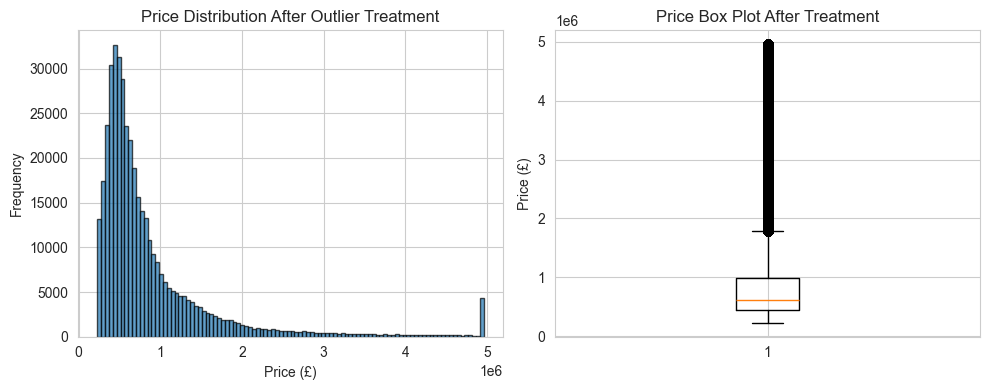


✅ Stage 1 Complete: Data cleaned and ready for Stage 2


In [16]:
# Winsorize price outliers (1% and 99% percentiles)
price_lower = merged_df['price'].quantile(0.01)
price_upper = merged_df['price'].quantile(0.99)

print(f'Price winsorizing bounds: £{price_lower:,.0f} - £{price_upper:,.0f}')

merged_df['price'] = np.clip(merged_df['price'], price_lower, price_upper)

# Verify outlier fix
print('\nPrice stats after outlier treatment:')
print(merged_df['price'].describe())

# Final price distribution plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(merged_df['price'], bins=100, edgecolor='black', alpha=0.7)
plt.title('Price Distribution After Outlier Treatment')
plt.xlabel('Price (£)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(merged_df['price'])
plt.title('Price Box Plot After Treatment')
plt.ylabel('Price (£)')

plt.tight_layout()
plt.savefig('price_distribution_cleaned.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Stage 1 Complete: Data cleaned and ready for Stage 2')